# Applied Machine Learning

## Assignment4 - ShunFai Lee

### Question1:

#### classification pipeline to predict whether a passenger on the Titanic survived

Using [titanic dataset - training](https://www.kaggle.com/datasets/yasserh/titanic-dataset) and [titanic dataset - testing](https://www.kaggle.com/datasets/brendan45774/test-file)

2 models will be used for evaluation:<br>
- logistic regression
- neural network

In [303]:
#import all needed libraries
from sklearn.model_selection import train_test_split,StratifiedKFold,cross_val_score,GridSearchCV,cross_validate
from sklearn.metrics import confusion_matrix, make_scorer, recall_score, precision_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
from io import StringIO
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn import tree, neural_network
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline, Pipeline

In [304]:
# Define some common functions
def tpr_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tp / (tp + fn)

def fpr_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return fp / (fp + tn)

def all_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {'tpr':tp / (tp + fn),
            'fpr':fp / (fp + tn),
            'precision':tp / (fp + tp),
            'accu':(tp+tn)/(tp+tn+fp+fn),
            'f1':(2*tp)/(2*tp+fp+fn)}

scoring_metrics = {
    'accuracy': 'accuracy',
    "tpr": make_scorer(tpr_score),
    "fpr": make_scorer(fpr_score),
    "precision": make_scorer(precision_score, zero_division=0)
}

In [305]:
# function to drop duplicate rows
def drop_dup(df:pd.DataFrame):
    df["is_duplicate"]= df.duplicated()
    index_to_drop = df[df['is_duplicate']==True].index
    if len(index_to_drop)==0:
        df.drop(columns='is_duplicate', inplace=True)
    else:
        df.drop(index_to_drop, inplace=True)
        df.drop(columns='is_duplicate', inplace=True)

#function to drop rows with less than half of features available
def drop_tooManyNA(df:pd.DataFrame):
    df.dropna(thresh=len(df.columns)//2,inplace=True)



#### Preprocessing of dataset

In [306]:
#load data set
df_train = pd.read_csv("train.csv")
df_test = pd.read_csv("test.csv")

print(df_train.dtypes)
print(f'train: total no.:{len(df_train)}')
print(f'test: total no.:{len(df_test)}')

for x in df_train.columns:
    print(f'number of null values at column {x}: {len(df_train[df_train[x].isnull()==True])}')

#drop entry with more than half NA values
drop_tooManyNA(df_train)
#drop duplicates
drop_dup(df_train)
#drop PassengerID, Names, tickets and cabin(too many NANs) for either unnecessary/not providing meaningful inference
df_train.drop(columns=['PassengerId','Name','Ticket','Cabin'],inplace=True)

testID = df_test['PassengerId']
df_test.drop(columns=['PassengerId','Name','Ticket','Cabin'],inplace=True)
#add dummy survived column, drop later
df_test["Survived"]=0

#define the columns that need some handling by types
numeric_cols = ['Age','Fare']
categorical_cols = ['Sex','Embarked']

#set up the pipelines for different columns, with differnt impute methods and standardization/one hot encode
numeric_transform = Pipeline([('imputer',SimpleImputer(strategy='mean')),('scaler',StandardScaler())])
cat_transform = Pipeline([('imputer',SimpleImputer(strategy='most_frequent')),('encoder',OneHotEncoder(categories='auto', drop='first'))])
other_transform = Pipeline([('imputer',SimpleImputer(strategy='most_frequent'))])

#set up the transformer
preprocessor = ColumnTransformer(transformers=[('numeric',numeric_transform,numeric_cols),('categorical',cat_transform,categorical_cols)],remainder=other_transform,verbose_feature_names_out=False)

#tranform and fit training data
df_train_encoded_X = pd.DataFrame(data=preprocessor.fit_transform(df_train),columns=preprocessor.get_feature_names_out()).drop(columns="Survived")
df_train_encoded_Y = df_train['Survived']

#transform test data
df_test_encoded_X = pd.DataFrame(data=preprocessor.transform(df_test),columns=preprocessor.get_feature_names_out()).drop(columns="Survived")


PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object
train: total no.:891
test: total no.:418
number of null values at column PassengerId: 0
number of null values at column Survived: 0
number of null values at column Pclass: 0
number of null values at column Name: 0
number of null values at column Sex: 0
number of null values at column Age: 177
number of null values at column SibSp: 0
number of null values at column Parch: 0
number of null values at column Ticket: 0
number of null values at column Fare: 0
number of null values at column Cabin: 687
number of null values at column Embarked: 2


#### logistic regression

In [307]:
#run a beseline logisticregression

print(f"run a logistic regression model")

pipe_lr = make_pipeline(LogisticRegression(max_iter= 500))
pipe_lr.fit(df_train_encoded_X, df_train_encoded_Y)
predicted_Y_LR = pipe_lr.predict(df_test_encoded_X)


run a logistic regression model


#### Neural network classifier with different layers

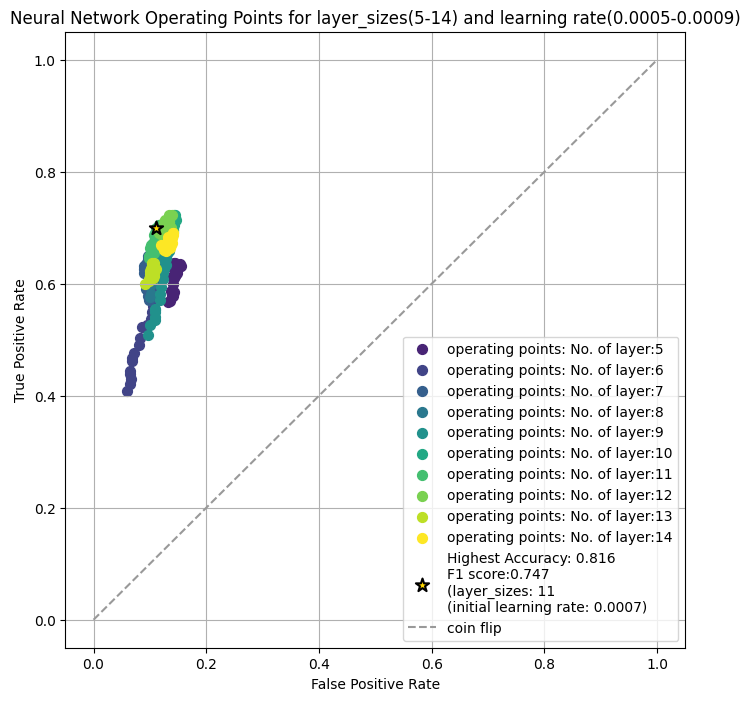

In [308]:
#define parameters for the model
n_layer = np.arange(5,15,1)
n_learningrate = np.linspace(0.0005,0.0009,30)
pipe_all= Pipeline([('model',neural_network.MLPClassifier(max_iter=500,random_state=42))])

param_grid = [{'model__hidden_layer_sizes': [(n,) for n in n_layer],'model__learning_rate_init': n_learningrate}]

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=1)
gs = GridSearchCV(estimator=pipe_all,param_grid=param_grid,scoring=scoring_metrics,refit='accuracy',cv=cv,n_jobs=-1)
gs.fit(df_train_encoded_X,df_train_encoded_Y)

#extract results
TPR = gs.cv_results_['mean_test_tpr']
FPR = gs.cv_results_['mean_test_fpr']
ACC = gs.cv_results_['mean_test_accuracy']
PRE = gs.cv_results_['mean_test_precision']

# Extract the first element of the tuple from layer parameter
layers = np.array([x[0] for x in gs.cv_results_['param_model__hidden_layer_sizes'].data])
ini_learning_rates = gs.cv_results_['param_model__learning_rate_init'].data

# Find the coordinates and data for the best model
best_idx = np.argmax(ACC)
best_fpr = FPR[best_idx]
best_tpr = TPR[best_idx]
best_acc = ACC[best_idx]
best_layer = layers[best_idx]
best_learning_rate = ini_learning_rates[best_idx]
best_pre = PRE[best_idx]
best_F1 = 2*best_pre*best_tpr/(best_pre+best_tpr)

#plot the graph
cmap = plt.cm.viridis
color_map = np.linspace(0.1,1,len(n_layer))
fig, ax = plt.subplots(1, figsize=(8, 8))
for i in range(len(n_layer)):
    indice = np.where(layers == n_layer[i])[0]
    TPR_i = TPR[indice]
    FPR_i = FPR[indice]
    fpr = [0.]+list(FPR_i)+[1.]; tpr = [0.]+list(TPR_i)+[1.]
    ax.scatter(FPR_i, TPR_i, 50, color=cmap(color_map[i]), marker='o', label=f'operating points: No. of layer:{n_layer[i]}')

#annotate the best operation point
ax.scatter(best_fpr, best_tpr, color='gold', marker='*', 
    s=100, edgecolor='black', linewidth=1.5,
    label=f'Highest Accuracy: {best_acc:.3f}\nF1 score:{best_F1:.3f}\n(layer_sizes: {best_layer}\n(initial learning rate: {best_learning_rate:.4f})', 
    zorder=4
)

ax.plot([0, 1], [0, 1], linestyle='--', color=(0.6, 0.6, 0.6), label='coin flip')
ax.set(xlabel='False Positive Rate', ylabel='True Positive Rate', title=f'Neural Network Operating Points for layer_sizes({n_layer[0]}-{n_layer[-1]}) and learning rate({n_learningrate[0]}-{n_learningrate[-1]})')
ax.grid(True)
plt.legend(loc='lower right')
plt.show()


predicted_Y_gs = gs.predict(df_test_encoded_X)

In implementing this classification pipeline, several features of the dataset are dropped, namely PassengerId, Name, Ticket, and cabin. PassengerId, Name and Ticket are dropped because in general they would not give any meaningful inference towards survival. Cabin is dropped because there are too many missing values (More than half of total data entries).
The dataset is furthered preprocessed by imputing missing numerical float values with mean, and categorical and other types with mode. Numerical values are also standardized to avoid too much weighting on some features.
All preprocessing except duplicate removal are then wrapped into a column transformer for efficient and organized preprocessing.

Finally, the preprocessed training dataset are passed to a logistic regression model and neural network for training. Below is a plot of statistics from the neural network:<br>
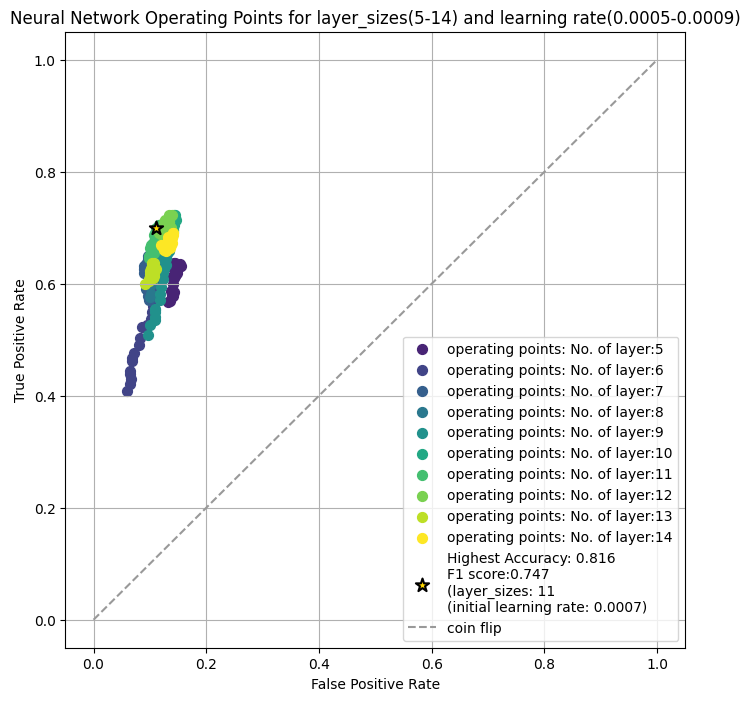

Both the logistic regression and neural network achieved a 0.7703 score on the test.
![Screenshot 2026-06-15 150625.png](<attachment:Screenshot 2026-06-15 150625.png>)

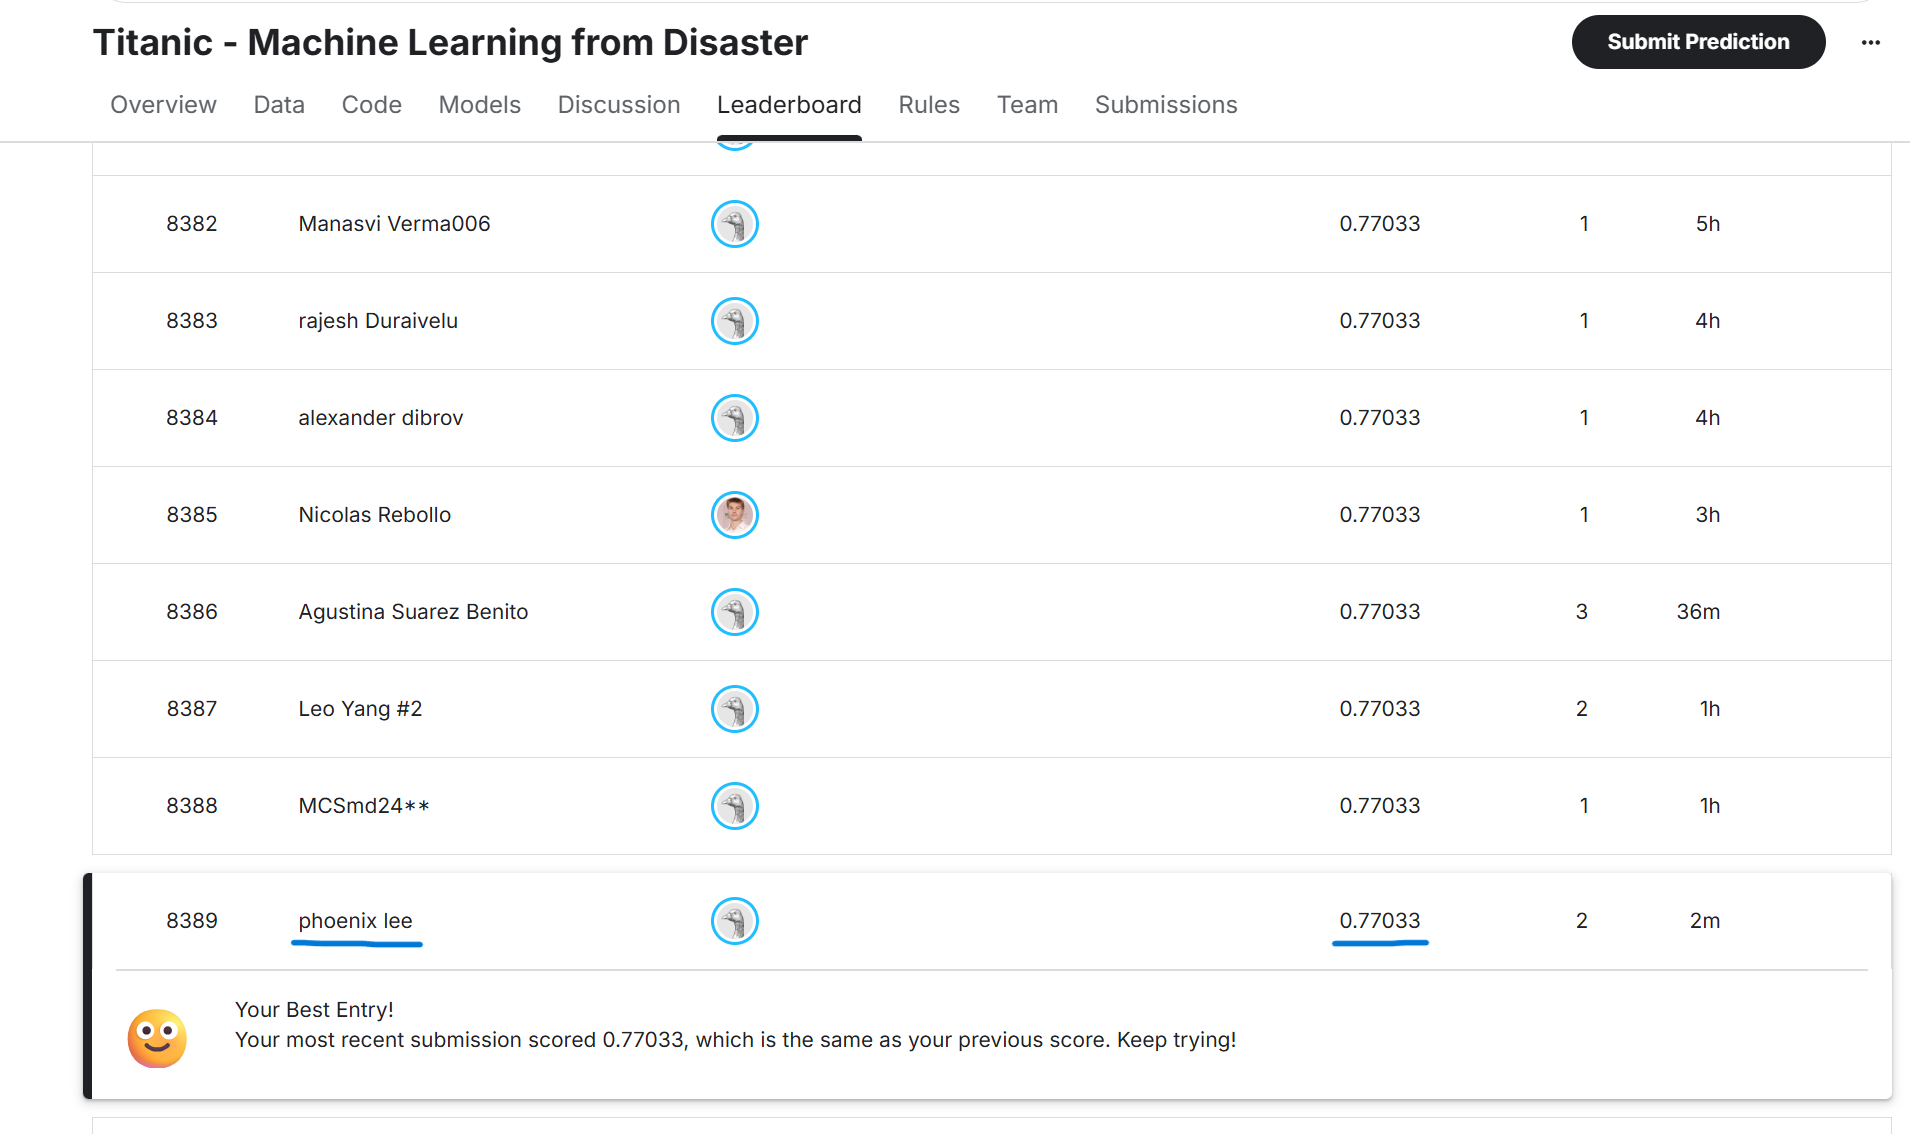

### Question 2
#### Export to Kaggle

In [311]:
def save_preds(_fn, _y_pred, _df): 
    import csv
    with open(_fn, 'w') as fout: 
        writer = csv.writer(fout, delimiter=',', lineterminator='\n') 
        writer.writerow(['PassengerId', 'Survived']) 
        for yid, ypred in zip(_df['PassengerId'], _y_pred): 
            writer.writerow([yid, ypred]) 
df_test_encoded_X_withID = df_test_encoded_X.copy()
df_test_encoded_X_withID['PassengerId'] = testID
save_preds('predictions_SLEE.csv', predicted_Y_LR, df_test_encoded_X_withID)
save_preds('predictions_SLEE2.csv', predicted_Y_gs, df_test_encoded_X_withID)
